<a href="https://colab.research.google.com/github/saniyaverma/DGFL-for-plant-disease-detection/blob/main/CL_Corn_Tomato_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import copy
import matplotlib.pyplot as plt
from PIL import Image
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# ============================================================
# GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

CHECKPOINT_DIR = "/content/drive/MyDrive/Centralized_Tomato-Corn"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Checkpoint directory:", CHECKPOINT_DIR)

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/Centralized_Tomato-Corn


In [3]:
# ============================================================
# SEED
# ============================================================

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
# ============================================================
# DATASET DOWNLOAD
# ============================================================

!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Tomato
!kaggle datasets download -d ashishmotwani/tomato
!kaggle datasets download -d kaustubhb999/tomatoleaf
!kaggle datasets download -d luisolazo/tomato-diseases

# Corn
!kaggle datasets download -d smaranjitghose/corn-or-maize-leaf-disease-dataset
!kaggle datasets download -d nafishamoin/new-bangladeshi-crop-disease
!kaggle datasets download -d karagwaanntreasure/plant-disease-detection

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
100% 1.37G/1.37G [00:08<00:00, 182MB/s]

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
100% 179M/179M [00:01<00:00, 141MB/s]

Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
100% 411M/411M [00:06<00:00, 63.8MB/s]

Dataset URL: https://www.kaggle.com/datasets/smaranjitghose/corn-or-maize-leaf-disease-dataset
License(s): copyright-authors
100% 161M/161M [00:01<00:00, 139MB/s]

Dataset URL: https://www.kaggle.com/datasets/nafishamoin/new-bangladeshi-crop-disease
License(s): copyright-authors
100% 2.35G/2.35G [00:16<00:00, 154MB/s]

Dataset URL: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection
License(s): MIT
100% 534M/534M [00:03<00:00, 151MB/s]



In [5]:
# ============================================================
# UNZIP
# ============================================================

!unzip -q tomato.zip -d tomato_A
!unzip -q tomatoleaf.zip -d tomato_B
!unzip -q tomato-diseases.zip -d tomato_unseen

!unzip -q corn-or-maize-leaf-disease-dataset.zip -d corn_A
!unzip -q new-bangladeshi-crop-disease.zip -d corn_B
!unzip -q plant-disease-detection.zip -d corn_unseen

In [6]:
# ============================================================
# REMOVE EXTRA CLASS
# ============================================================
# **Corn had no extra classes

paths_to_delete = [
    "tomato_A/train/powdery_mildew",
    "tomato_A/valid/powdery_mildew"
]

for p in paths_to_delete:
    if os.path.exists(p):
        shutil.rmtree(p)

In [7]:
# ============================================================
# DATASET SCANNER
# ============================================================

def scan_dataset(root_dir, dataset_name):

    records = []

    for root, dirs, files in os.walk(root_dir):

        for file in files:

            if file.lower().endswith((".jpg",".png",".jpeg")):

                path = os.path.join(root,file)
                label = os.path.basename(root)

                records.append({
                    "dataset":dataset_name,
                    "path":path,
                    "raw_label":label
                })

    return pd.DataFrame(records)

df_A = scan_dataset("tomato_A","A")
df_B = scan_dataset("tomato_B/tomato","B")
df_C = scan_dataset("tomato_unseen","C")

df_D = scan_dataset("corn_A","D")
df_E = scan_dataset("corn_B","E")
df_F = scan_dataset("corn_unseen","F")

df_raw = pd.concat([df_A,df_B,df_C,df_D,df_E,df_F]).reset_index(drop=True)

print("Total images:",len(df_raw))

Total images: 118971


In [8]:
# ============================================================
# LABEL HARMONIZATION
# ============================================================

canonical_labels = [
"bacterial_spot","early_blight","late_blight","leaf_mold",
"mosaic_virus","septoria_leaf_spot","spider_mites",
"target_spot","yellow_leaf_curl_virus","tomato_healthy",
"common_rust","gray_leaf_spot","blight","corn_healthy"
]

label_to_id = {l:i for i,l in enumerate(canonical_labels)}

def harmonize(row):

    l = row["raw_label"].lower()
    d = row["dataset"]

    # Tomato
    if d in ["A","B","C"]:
        if "healthy" in l: return "tomato_healthy"
        if "bacterial" in l: return "bacterial_spot"
        if "early" in l: return "early_blight"
        if "late" in l: return "late_blight"
        if "mold" in l: return "leaf_mold"
        if "mosaic" in l: return "mosaic_virus"
        if "septoria" in l: return "septoria_leaf_spot"
        if "spider" in l: return "spider_mites"
        if "target" in l: return "target_spot"
        if "yellow" in l: return "yellow_leaf_curl_virus"

    # Corn
    else:
        if "healthy" in l: return "corn_healthy"
        if "rust" in l: return "common_rust"
        if "gray" in l: return "gray_leaf_spot"
        if "blight" in l: return "blight"

df_raw["canonical_label"]=df_raw.apply(harmonize,axis=1)
df_raw=df_raw[df_raw["canonical_label"].notnull()]
df_raw["class_id"]=df_raw["canonical_label"].map(label_to_id)

client_map={"A":0,"B":1,"C":2,"D":3,"E":4,"F":5}
df_raw["domain"]=df_raw["dataset"].map(client_map)

df_all=df_raw.copy()

In [9]:
# ============================================================
# DATA SPLIT
# ============================================================

def split_domain(df,domain):

    d=df[df.domain==domain]

    train,temp=train_test_split(
        d,
        train_size=0.7,
        stratify=d.class_id,
        random_state=42
    )

    val,test=train_test_split(
        temp,
        train_size=0.5,
        stratify=temp.class_id,
        random_state=42
    )

    return train,val,test

train_A,val_A,test_A=split_domain(df_all,0)
train_B,val_B,test_B=split_domain(df_all,1)
train_D,val_D,test_D=split_domain(df_all,3)
train_E,val_E,test_E=split_domain(df_all,4)

test_C=df_all[df_all.domain==2]
test_F=df_all[df_all.domain==5]

In [10]:
# ============================================================
# CENTRALIZED TRAIN SET
# ============================================================

train_df=pd.concat([train_A,train_B,train_D,train_E])
val_df=pd.concat([val_A,val_B,val_D,val_E])

print("Train:",len(train_df))
print("Val:",len(val_df))

print("Test A:",len(test_A))
print("Test B:",len(test_B))
print("Test D:",len(test_D))
print("Test E:",len(test_E))

print("Test C:",len(test_C))
print("Test F:",len(test_F))

Train: 39827
Val: 8535
Test A: 4692
Test B: 1651
Test D: 629
Test E: 1566
Test C: 22193
Test F: 19214


In [11]:
# ============================================================
# TRANSFORMS
# ============================================================

train_transform=transforms.Compose([
transforms.Resize((256,256)),
transforms.RandomResizedCrop(224,scale=(0.7,1.0)),
transforms.RandomHorizontalFlip(),
transforms.RandomRotation(20),
transforms.ColorJitter(0.3,0.3,0.3,0.05),
transforms.ToTensor(),
transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_transform=transforms.Compose([
transforms.Resize((224,224)),
transforms.ToTensor(),
transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [12]:
# ============================================================
# DATASET CLASS
# ============================================================

class PlantDataset(Dataset):

    def __init__(self,df,transform=None):
        self.df=df.reset_index(drop=True)
        self.transform=transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):

        path=self.df.loc[idx,"path"]
        label=self.df.loc[idx,"class_id"]

        img=Image.open(path).convert("RGB")

        if self.transform:
            img=self.transform(img)

        return img,label

In [13]:
# ============================================================
# LOADERS
# ============================================================

BATCH=32

train_loader=DataLoader(PlantDataset(train_df,train_transform),batch_size=BATCH,shuffle=True)
val_loader=DataLoader(PlantDataset(val_df,test_transform),batch_size=BATCH)

test_loader_A=DataLoader(PlantDataset(test_A,test_transform),batch_size=BATCH)
test_loader_B=DataLoader(PlantDataset(test_B,test_transform),batch_size=BATCH)
test_loader_D=DataLoader(PlantDataset(test_D,test_transform),batch_size=BATCH)
test_loader_E=DataLoader(PlantDataset(test_E,test_transform),batch_size=BATCH)

test_loader_C=DataLoader(PlantDataset(test_C,test_transform),batch_size=BATCH)
test_loader_F=DataLoader(PlantDataset(test_F,test_transform),batch_size=BATCH)

test_loader_CF=DataLoader(
    PlantDataset(pd.concat([test_C,test_F]),test_transform),
    batch_size=BATCH
)

In [14]:
# ============================================================
# CLASS WEIGHTS
# ============================================================

counts=train_df.class_id.value_counts().sort_index()
weights=1.0/counts
weights=torch.tensor(weights.values,dtype=torch.float32).to(device)

In [15]:
# ============================================================
# MODEL
# ============================================================

model=resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc=nn.Linear(model.fc.in_features,len(canonical_labels))
model=model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 114MB/s]


In [16]:
# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion=nn.CrossEntropyLoss(weight=weights,label_smoothing=0.1)
optimizer=optim.Adam(model.parameters(),lr=3e-5)

In [17]:
# ============================================================
# CHECKPOINT LOADER
# ============================================================

def load_latest_checkpoint():

    files = [f for f in os.listdir(CHECKPOINT_DIR) if "latest_epoch" in f]

    if len(files) == 0:
        return None, 0

    files.sort()

    latest = files[-1]

    path = os.path.join(CHECKPOINT_DIR, latest)

    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1

    print("Loaded checkpoint:", latest)

    return checkpoint, start_epoch

checkpoint, start_epoch = load_latest_checkpoint()

if checkpoint is None:
    print("Starting training from scratch")
    best_val = 0
    best_model = copy.deepcopy(model.state_dict())
else:
    print(f"Resuming from epoch {start_epoch}")
    best_val = checkpoint["best_val"]
    best_model = checkpoint["best_model"]

Starting training from scratch


In [18]:
# ============================================================
# TRAINING LOOP WITH CHECKPOINTS
# ============================================================

from tqdm import tqdm

EPOCHS = 10

for epoch in range(start_epoch, EPOCHS):

    model.train()
    running_loss = 0

    for images,labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # VALIDATION
    model.eval()
    correct,total = 0,0

    with torch.no_grad():
        for images,labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs,1)

            total += labels.size(0)
            correct += (preds==labels).sum().item()

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1} | Loss {running_loss:.4f} | Val {val_acc:.2f}")

    # BEST MODEL
    if val_acc > best_val:
        best_val = val_acc
        best_model = copy.deepcopy(model.state_dict())

        torch.save({
            "epoch": epoch,
            "best_val": best_val,
            "model_state_dict": best_model
        }, os.path.join(CHECKPOINT_DIR,"best_model.pth"))

        print("Best model saved")

    # SAVE CHECKPOINT
    checkpoint_path = os.path.join(
        CHECKPOINT_DIR,
        f"latest_epoch_{epoch+1}.pth"
    )

    torch.save({
        "epoch": epoch,
        "best_val": best_val,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_model": best_model
    }, checkpoint_path)

    print("Checkpoint saved:", checkpoint_path)

100%|██████████| 1245/1245 [09:09<00:00,  2.26it/s]


Epoch 1 | Loss 1301.2438 | Val 94.24
Best model saved
Checkpoint saved: /content/drive/MyDrive/Centralized_Tomato-Corn/latest_epoch_1.pth


100%|██████████| 1245/1245 [08:35<00:00,  2.41it/s]


Epoch 2 | Loss 1003.2568 | Val 96.45
Best model saved
Checkpoint saved: /content/drive/MyDrive/Centralized_Tomato-Corn/latest_epoch_2.pth


100%|██████████| 1245/1245 [08:39<00:00,  2.40it/s]


...

Epoch 8 | Loss 844.1098 | Val 98.49
Best model saved
Checkpoint saved: /content/drive/MyDrive/Centralized_Tomato-Corn/latest_epoch_8.pth


100%|██████████| 1245/1245 [08:35<00:00,  2.41it/s]


Epoch 9 | Loss 834.8439 | Val 98.83
Best model saved
Checkpoint saved: /content/drive/MyDrive/Centralized_Tomato-Corn/latest_epoch_9.pth


100%|██████████| 1245/1245 [08:45<00:00,  2.37it/s]


Epoch 10 | Loss 828.3186 | Val 98.91
Best model saved
Checkpoint saved: /content/drive/MyDrive/Centralized_Tomato-Corn/latest_epoch_10.pth


In [19]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

best_checkpoint = torch.load(os.path.join(CHECKPOINT_DIR,"best_model.pth"), map_location=device)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [22]:
def evaluate(loader,name):

    preds=[]
    labels_true=[]

    with torch.no_grad():
        for images,l in loader:

            images=images.to(device)
            outputs=model(images)

            p=torch.argmax(outputs,1).cpu().numpy()

            preds.extend(p)
            labels_true.extend(l.numpy())

    print("\n==============================")
    print(name)
    print("==============================")

    # ✅ IMPORTANT FIX HERE
    print(classification_report(
        labels_true,
        preds,
        labels=list(range(len(canonical_labels))),  # force all 14 classes
        target_names=canonical_labels,
        zero_division=0
    ))

    cm=confusion_matrix(
        labels_true,
        preds,
        labels=list(range(len(canonical_labels)))  # also fix CM
    )

    bal_acc = balanced_accuracy_score(labels_true, preds)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=canonical_labels,
        yticklabels=canonical_labels,
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(name+" Confusion Matrix")

    print("Balanced Accuracy:",round(bal_acc*100, 2), "%")

    plt.show()


IID TEST - Tomato A
                        precision    recall  f1-score   support

        bacterial_spot       0.99      0.96      0.98       533
          early_blight       0.97      0.98      0.98       464
           late_blight       0.99      0.98      0.98       586
             leaf_mold       0.99      0.99      0.99       524
          mosaic_virus       0.99      0.98      0.99       411
    septoria_leaf_spot       0.97      0.99      0.98       545
          spider_mites       0.99      1.00      1.00       328
           target_spot       1.00      0.99      0.99       342
yellow_leaf_curl_virus       0.99      1.00      1.00       381
        tomato_healthy       0.98      1.00      0.99       578
           common_rust       0.00      0.00      0.00         0
        gray_leaf_spot       0.00      0.00      0.00         0
                blight       0.00      0.00      0.00         0
          corn_healthy       0.00      0.00      0.00         0

              acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Balanced Accuracy: 98.59 %


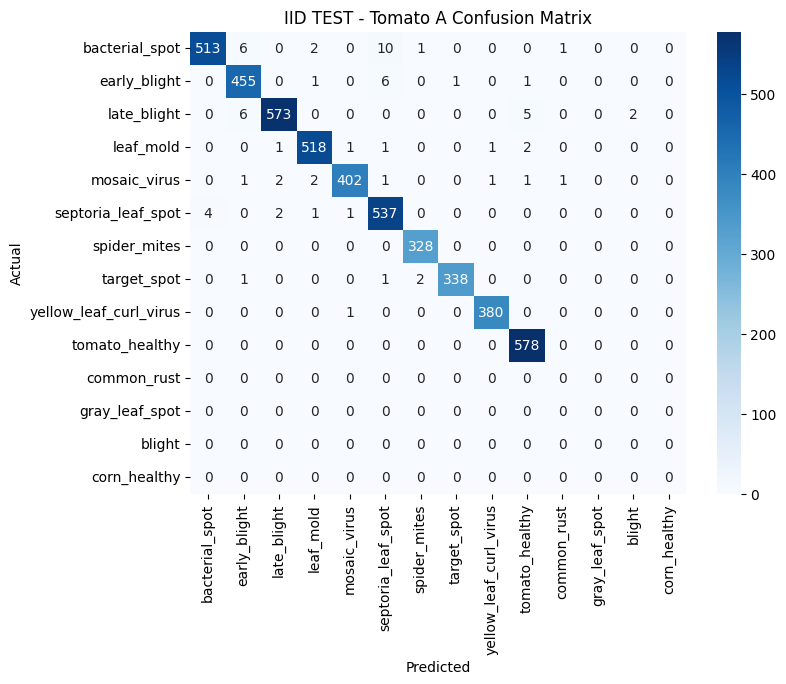


IID TEST - Tomato B
                        precision    recall  f1-score   support

        bacterial_spot       1.00      0.99      1.00       165
          early_blight       1.00      1.00      1.00       165
           late_blight       1.00      0.99      1.00       165
             leaf_mold       1.00      1.00      1.00       165
          mosaic_virus       1.00      1.00      1.00       165
    septoria_leaf_spot       1.00      1.00      1.00       165
          spider_mites       0.99      1.00      1.00       166
           target_spot       1.00      0.99      1.00       165
yellow_leaf_curl_virus       0.99      1.00      1.00       165
        tomato_healthy       0.99      1.00      1.00       165
           common_rust       0.00      0.00      0.00         0
        gray_leaf_spot       0.00      0.00      0.00         0
                blight       0.00      0.00      0.00         0
          corn_healthy       0.00      0.00      0.00         0

              acc

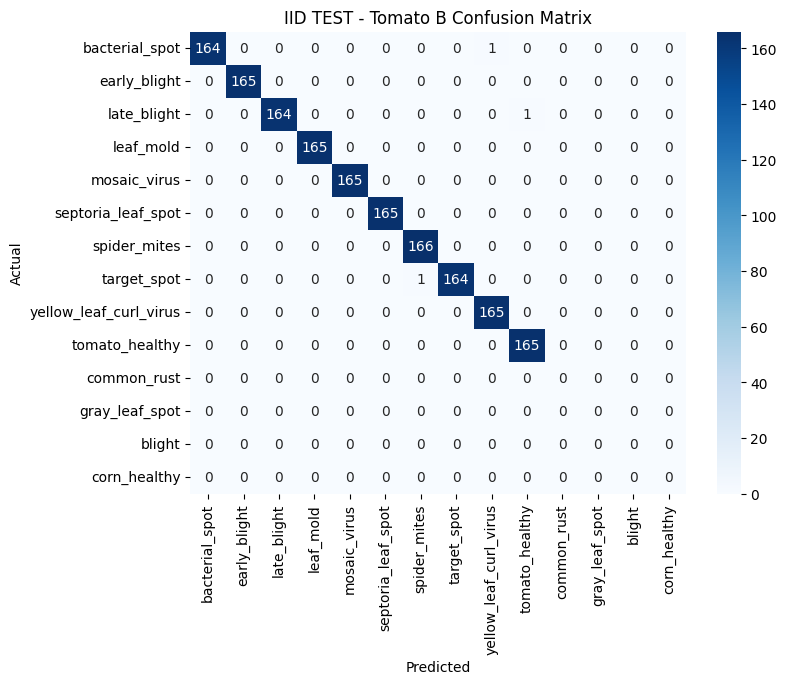


IID TEST - Corn A
                        precision    recall  f1-score   support

        bacterial_spot       0.00      0.00      0.00         0
          early_blight       0.00      0.00      0.00         0
           late_blight       0.00      0.00      0.00         0
             leaf_mold       0.00      0.00      0.00         0
          mosaic_virus       0.00      0.00      0.00         0
    septoria_leaf_spot       0.00      0.00      0.00         0
          spider_mites       0.00      0.00      0.00         0
           target_spot       0.00      0.00      0.00         0
yellow_leaf_curl_virus       0.00      0.00      0.00         0
        tomato_healthy       0.00      0.00      0.00         0
           common_rust       0.99      0.99      0.99       196
        gray_leaf_spot       0.95      0.90      0.92        86
                blight       0.94      0.97      0.95       172
          corn_healthy       1.00      1.00      1.00       175

              accur

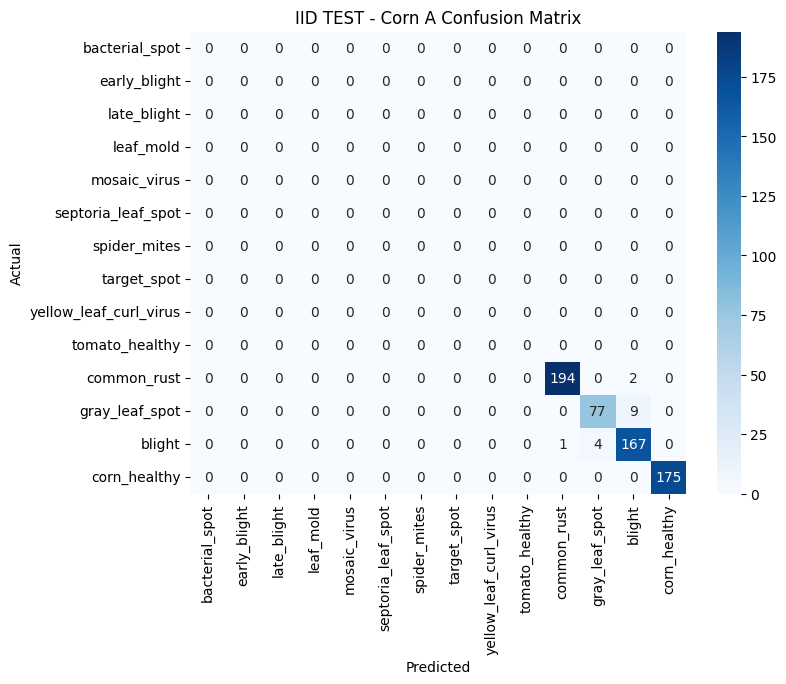


IID TEST - Corn B
                        precision    recall  f1-score   support

        bacterial_spot       0.00      0.00      0.00         0
          early_blight       0.00      0.00      0.00         0
           late_blight       0.00      0.00      0.00         0
             leaf_mold       0.00      0.00      0.00         0
          mosaic_virus       0.00      0.00      0.00         0
    septoria_leaf_spot       0.00      0.00      0.00         0
          spider_mites       0.00      0.00      0.00         0
           target_spot       0.00      0.00      0.00         0
yellow_leaf_curl_virus       0.00      0.00      0.00         0
        tomato_healthy       0.00      0.00      0.00         0
           common_rust       1.00      0.99      1.00       453
        gray_leaf_spot       0.96      0.94      0.95        77
                blight       0.99      0.99      0.99       448
          corn_healthy       1.00      1.00      1.00       588

              accur

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


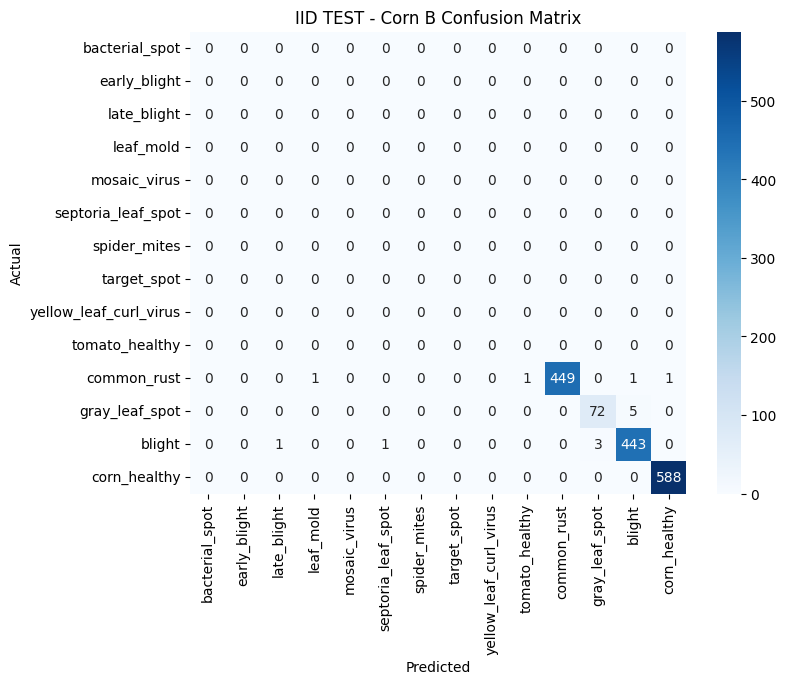


OOD TEST - Tomato C
                        precision    recall  f1-score   support

        bacterial_spot       0.95      1.00      0.97      2123
          early_blight       0.98      0.79      0.87      2621
           late_blight       0.82      0.90      0.86      2537
             leaf_mold       0.93      1.00      0.96      1904
          mosaic_virus       0.99      1.00      1.00      1641
    septoria_leaf_spot       0.80      1.00      0.89      1771
          spider_mites       0.95      1.00      0.97      1676
           target_spot       0.99      0.99      0.99      1554
yellow_leaf_curl_virus       1.00      1.00      1.00      4039
        tomato_healthy       0.98      0.75      0.85      2327
           common_rust       0.00      0.00      0.00         0
        gray_leaf_spot       0.00      0.00      0.00         0
                blight       0.00      0.00      0.00         0
          corn_healthy       0.00      0.00      0.00         0

              acc

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Balanced Accuracy: 94.27 %


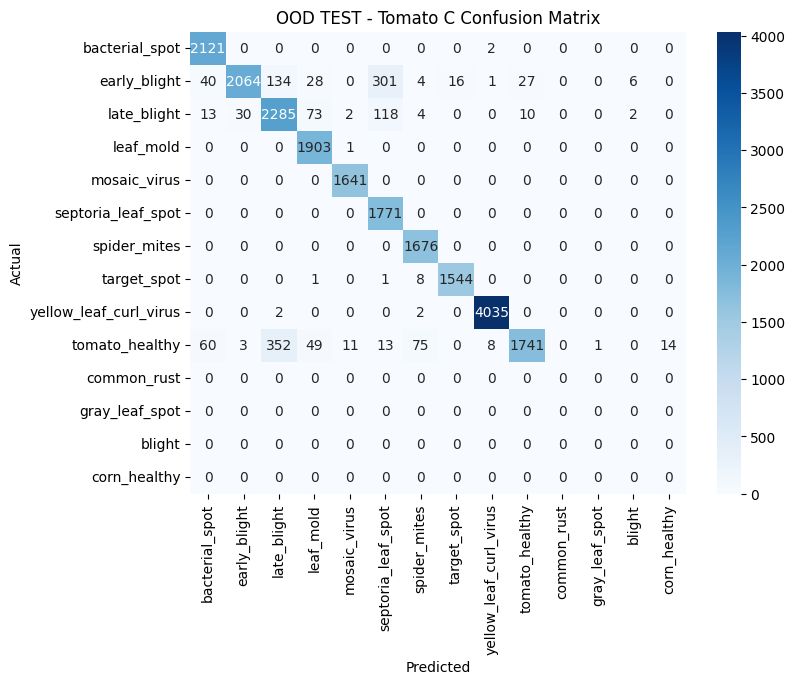


OOD TEST - Corn C
                        precision    recall  f1-score   support

        bacterial_spot       0.00      0.00      0.00         0
          early_blight       0.00      0.00      0.00         0
           late_blight       0.00      0.00      0.00         0
             leaf_mold       0.00      0.00      0.00         0
          mosaic_virus       0.00      0.00      0.00         0
    septoria_leaf_spot       0.00      0.00      0.00         0
          spider_mites       0.00      0.00      0.00         0
           target_spot       0.00      0.00      0.00         0
yellow_leaf_curl_virus       0.00      0.00      0.00         0
        tomato_healthy       0.00      0.00      0.00         0
           common_rust       0.99      0.52      0.68      3667
        gray_leaf_spot       0.91      0.84      0.87      1642
                blight       0.83      0.57      0.67      6817
          corn_healthy       1.00      0.42      0.59      7088

              accur

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Balanced Accuracy: 58.73 %


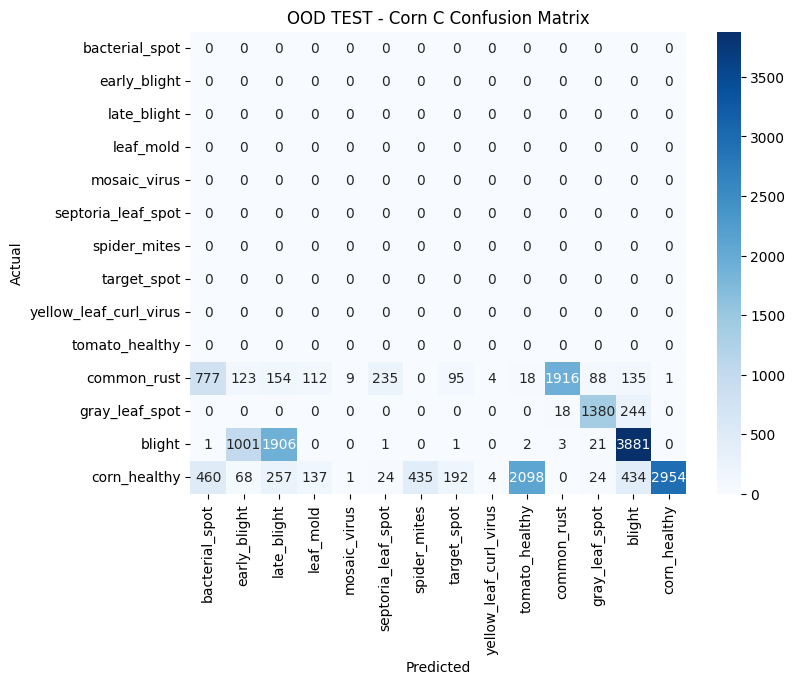


OOD TEST - Tomato + Corn Combined
                        precision    recall  f1-score   support

        bacterial_spot       0.61      1.00      0.76      2123
          early_blight       0.63      0.79      0.70      2621
           late_blight       0.45      0.90      0.60      2537
             leaf_mold       0.83      1.00      0.90      1904
          mosaic_virus       0.99      1.00      0.99      1641
    septoria_leaf_spot       0.72      1.00      0.84      1771
          spider_mites       0.76      1.00      0.86      1676
           target_spot       0.84      0.99      0.91      1554
yellow_leaf_curl_virus       1.00      1.00      1.00      4039
        tomato_healthy       0.45      0.75      0.56      2327
           common_rust       0.99      0.52      0.68      3667
        gray_leaf_spot       0.91      0.84      0.87      1642
                blight       0.83      0.57      0.67      6817
          corn_healthy       0.99      0.42      0.59      7088

   

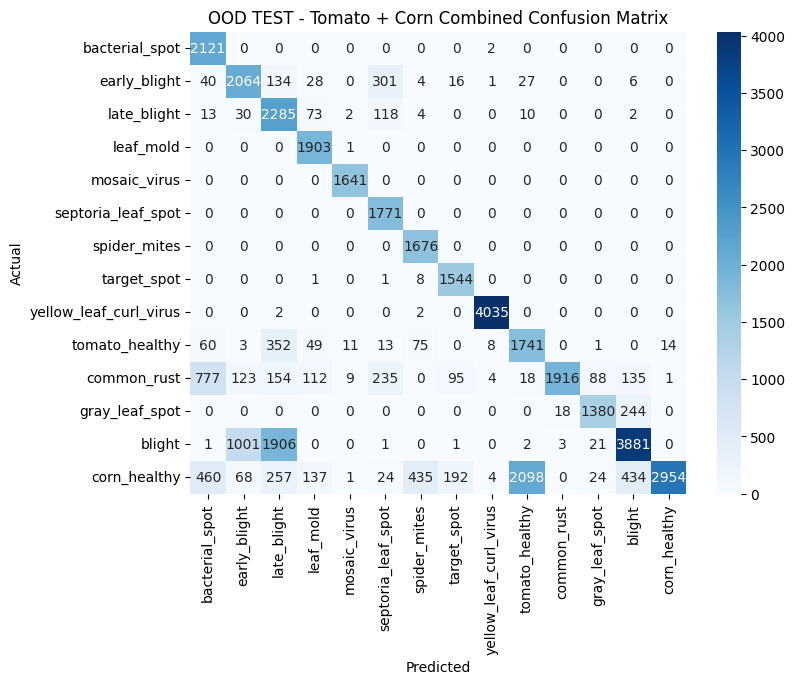

In [23]:
# ============================================================
# IID + OOD TESTS
# ============================================================

evaluate(test_loader_A,"IID TEST - Tomato A")
evaluate(test_loader_B,"IID TEST - Tomato B")
evaluate(test_loader_D,"IID TEST - Corn A")
evaluate(test_loader_E,"IID TEST - Corn B")

evaluate(test_loader_C,"OOD TEST - Tomato C")
evaluate(test_loader_F,"OOD TEST - Corn C")

evaluate(test_loader_CF,"OOD TEST - Tomato + Corn Combined")